# 03 — Model Training

We train and tune two classifiers for **high-risk customer detection**:

| Model | Role |
|-------|------|
| **XGBoost** | Primary gradient-boosted model |
| **Random Forest** | Interpretable benchmark |

Both pipelines use **SMOTETomek** inside cross-validation (train only) and **MLflow** logging.

```mermaid
flowchart TB
    X[Train features] --> P[Preprocessor]
    P --> S[SMOTETomek]
    S --> M[XGBoost / Random Forest]
    M --> T[Threshold tuning on train proba]
    T --> E[Test metrics]
```


In [1]:
from pathlib import Path
import sys

def find_ml_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / '4_ml' / 'src').exists():
            return candidate / '4_ml'
        if candidate.name == '4_ml' and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the 4_ml workspace.')

ML_ROOT = find_ml_root()
if str(ML_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ML_ROOT / 'src'))

import json
import os
import numpy as np
import pandas as pd

from config import OUTPUT_DIR
from data_access import load_feature_frame
from features import build_model_frame, engineer_features, select_feature_columns, split_temporal
from modeling import build_model_specs, evaluate_model, log_metrics_and_artifacts, optimize_threshold, tune_model

raw = load_feature_frame()
max_rows = int(os.getenv('ATB_NOTEBOOK_MAX_ROWS', '8000'))
if len(raw) > max_rows:
    raw = raw.sample(max_rows, random_state=42).sort_values('scoring_date').reset_index(drop=True)
    print(f'Sampled {max_rows:,} rows for interactive training (set ATB_NOTEBOOK_MAX_ROWS for full data)')
frame = build_model_frame(raw)
engineered = engineer_features(frame)
engineered = engineered.loc[:, ~engineered.columns.duplicated()].copy()
feature_columns, numeric_columns, categorical_columns = select_feature_columns(engineered)
feature_columns = list(dict.fromkeys(feature_columns))
train_frame, test_frame = split_temporal(engineered, date_column='scoring_date', test_fraction=0.2)
train_frame = train_frame.loc[:, ~train_frame.columns.duplicated()].copy()
test_frame = test_frame.loc[:, ~test_frame.columns.duplicated()].copy()
X_train = train_frame[feature_columns].copy()
y_train = train_frame['risk_target'].astype(int)
X_test = test_frame[feature_columns].copy()
y_test = test_frame['risk_target'].astype(int)

feature_columns[:10], len(feature_columns)

Sampled 8,000 rows for interactive training (set ATB_NOTEBOOK_MAX_ROWS for full data)


(['customer_tenure_days',
  'account_count',
  'total_working_balance',
  'avg_working_balance',
  'negative_balance_account_count',
  'monthly_salary',
  'number_of_dependents',
  'days_since_last_kyc_review',
  'days_until_next_kyc_review',
  'balance_per_account'],
 33)

In [2]:
specs = build_model_specs(numeric_columns, categorical_columns)
search_results = {}
for spec in specs:
    search = tune_model(spec, X_train, y_train, n_iter=3)
    threshold, best_f1 = optimize_threshold(y_train, search.best_estimator_.predict_proba(X_train)[:, 1])
    search_results[spec.name] = {
        'search': search,
        'threshold': threshold,
        'train_f1_at_threshold': best_f1,
    }
search_results.keys()

Fitting 2 folds for each of 3 candidates, totalling 6 fits


Fitting 2 folds for each of 3 candidates, totalling 6 fits


dict_keys(['xgboost', 'random_forest'])

In [3]:
evaluation_rows = []
for name, payload in search_results.items():
    search = payload['search']
    threshold = payload['threshold']
    metrics = evaluate_model(search.best_estimator_, X_test, y_test, threshold=threshold)
    metrics['threshold'] = threshold
    metrics['model_name'] = name
    evaluation_rows.append(metrics)
    log_metrics_and_artifacts(
        model_name=name,
        best_model=search.best_estimator_,
        metrics={key: value for key, value in metrics.items() if key not in {'model_name'}},
        param_summary=search.best_params_,
        artifact_filename=f'{name}_best_model.joblib',
    )

evaluation_frame = pd.DataFrame(evaluation_rows).sort_values('f1', ascending=False)
evaluation_frame

C:\Users\Ahmed\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


,accuracy,f1,precision,recall,roc_auc,pr_auc,brier_score,threshold,model_name
0,0.999375,0.981818,1.0,0.964286,0.994866,0.967794,0.00069,0.967016,xgboost
1,0.995625,0.857143,1.0,0.750000,0.994388,0.957735,0.00956,0.622636,random_forest


In [4]:
best_row = evaluation_frame.iloc[0]
best_model_name = best_row['model_name']
best_model = search_results[best_model_name]['search'].best_estimator_
best_threshold = search_results[best_model_name]['threshold']

final_metrics = evaluate_model(best_model, X_test, y_test, threshold=best_threshold)
final_metrics['threshold'] = best_threshold
final_metrics['model_name'] = best_model_name
final_metrics

{'accuracy': 0.999375,
 'f1': 0.9818181818181818,
 'precision': 1.0,
 'recall': 0.9642857142857143,
 'roc_auc': 0.9948655034532897,
 'pr_auc': 0.9677944862155389,
 'brier_score': 0.000690238899551332,
 'threshold': 0.9670161604881287,
 'model_name': 'xgboost'}

In [5]:
pred_proba = best_model.predict_proba(X_test)[:, 1]
pred_df = test_frame[['customer_id', 'scoring_date', 'risk_target']].copy()
pred_df['risk_probability'] = pred_proba
pred_df['risk_prediction'] = (pred_df['risk_probability'] >= best_threshold).astype(int)
pred_df.to_csv(OUTPUT_DIR / 'risk_predictions_test_set.csv', index=False)
pred_df.head()

,customer_id,scoring_date,risk_target,risk_probability,risk_prediction
6400,113093696,2026-05-18,0,0.001180,0
6401,113265671,2026-05-18,0,0.001180,0
6402,113172446,2026-05-18,1,0.995584,1
6403,113833194,2026-05-18,0,0.003080,0
6404,113842052,2026-05-18,0,0.001180,0


Wrote C:\Users\Ahmed\Desktop\atb_bi_project\4_ml\outputs\training_summary.json


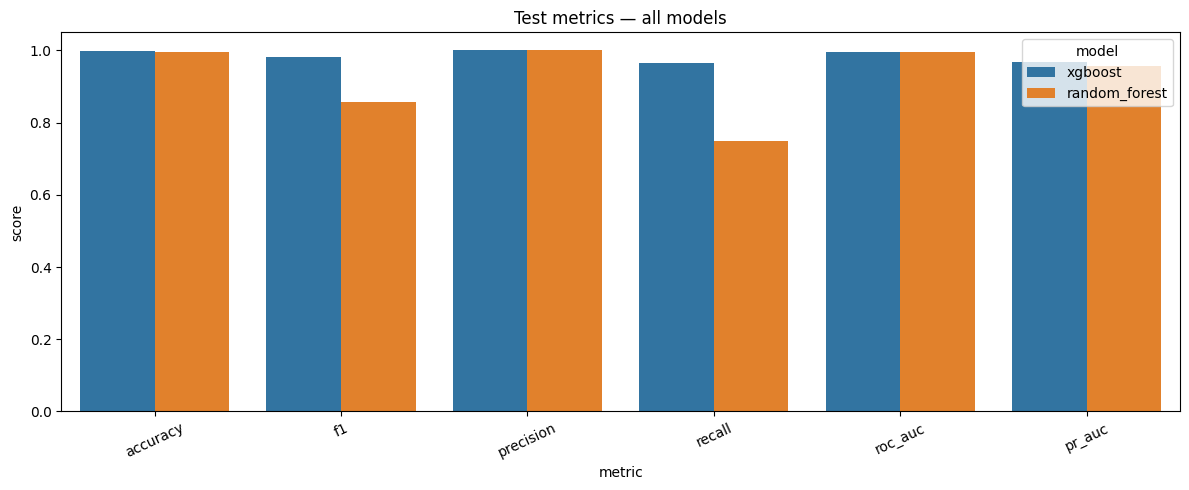

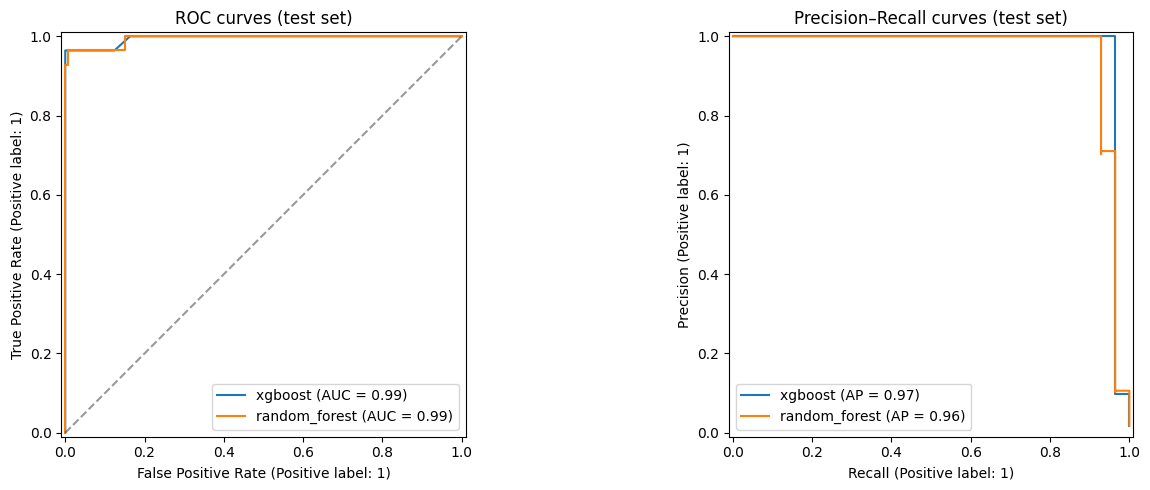

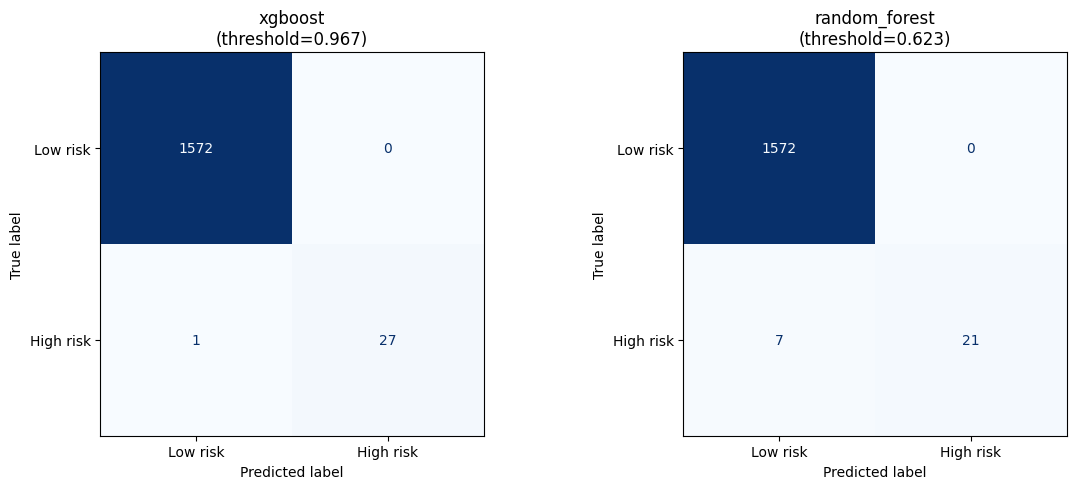

In [6]:
# Save training summary + comparison plots for notebook 05
training_summary = {"best_model": evaluation_frame.iloc[0]["model_name"], "results": {}}
for name, payload in search_results.items():
    m = evaluate_model(
        payload["search"].best_estimator_, X_test, y_test, threshold=payload["threshold"]
    )
    training_summary["results"][name] = {
        "metrics": m,
        "best_params": payload["search"].best_params_,
        "threshold": payload["threshold"],
    }

summary_path = OUTPUT_DIR / "training_summary.json"
summary_path.write_text(json.dumps(training_summary, indent=2), encoding="utf-8")
print(f"Wrote {summary_path}")

# Model comparison visuals
import matplotlib.pyplot as plt
from notebook_helpers import plot_roc_pr_grid, plot_confusion_matrices, metrics_comparison_bar
trained = {n: search_results[n]["search"].best_estimator_ for n in search_results}
thresholds = {n: search_results[n]["threshold"] for n in search_results}

comparison_df = evaluation_frame.copy()
fig = metrics_comparison_bar(comparison_df.rename(columns={"model_name": "model"}), title="Test metrics — all models")
fig.savefig(OUTPUT_DIR / "03_model_comparison_bars.png", bbox_inches="tight")
plt.show()

roc_fig = plot_roc_pr_grid(trained, X_test, y_test)
roc_fig.savefig(OUTPUT_DIR / "03_roc_pr_comparison.png", bbox_inches="tight")
plt.show()

cm_fig = plot_confusion_matrices(trained, X_test, y_test, thresholds)
cm_fig.savefig(OUTPUT_DIR / "03_confusion_matrices.png", bbox_inches="tight")
plt.show()


## Modeling notes

- XGBoost is the primary model.
- Random Forest is kept as a benchmark.
- SMOTETomek is applied inside the training pipeline to handle class imbalance without touching the test set.
- The evaluation frame records Accuracy, F1, ROC-AUC, Brier score, and PR-AUC.
- MLflow logging is enabled with a local file-based fallback unless a tracking URI is supplied.